# FIP 16 — RPE coding in DA and NE

How do DA and NE code reward and RPE at the outcome, how alike is their coding, how are their outcome
responses coupled beyond it, what do the pre-cue baselines carry, and does movement after the outcome
account for the RPE terms?

1. Outcome responses and RPE terms: `response ~ reward + RPE·rewarded + RPE·unrewarded + RT + trial
   position` per session, in three windows
2. The same regression at every time point after the outcome
3. DA's coefficients against NE's (trial, session and animal level)
4. Trial-by-trial DA–NE coupling of outcome responses beyond outcome and RPE, with controls
5. Pre-cue baselines: value and DA–NE coupling
6. RPE terms with movement (ME) after the outcome as a covariate (sessions with a usable bottom camera)
7. Numbers

`fip_15` has the task-aligned averages by RPE group from Rachel's pipeline, and `fip_17` the choice
of trial split for her RPE slopes.

**Signals.** DA: dLight in lateral NAc (`latNAcc(X)-DA`). NE: GCaMP in LC noradrenergic axons
imaged in PL (`PL(X)-LCAxonCa`), i.e. axonal calcium. Both are `dff-bright_mc-iso-IRLS` dF/F at
20 Hz. The two indicators have different kinetics, so lags describe the recorded signals, not
timing in the brain.

**Movement** is motion energy (ME) from the bottom camera: the summed absolute frame-to-frame pixel
change, from the aligned ME table (`fip_motion_energy_aligned`, frame times corrected by the video
timing QC). Cameras that fail the video timing or quality screen are left out (`men_01`).

**Data.** The CSV-curated `DANE_3channels_curated` and `DANE_4channels_curated` assets. Each animal
contributes one hemisphere (the side with more sessions), with DA and NE from that side; animals
need at least 3 sessions (`fu.inventory_pairs`, `fu.choose_side`, `fu.load_pairs`). Traces sit on
one 20 Hz grid from 5 s before the first go cue to 10 s after the last; ME is averaged into the same
bins (`fu.add_motion_energy`). Each trace is z-scored over the session.

**Statistics.** Session values are averaged within animal; tests are Wilcoxon signed-rank on animal
means (smallest two-sided p with 9 animals: 0.004). Error bands are SEM over animals.

RPE is `RPE_earned` (earned reward − Q_chosen, per-session Q-learning fit). Trials with extra
(unearned) water are left out. Per-trial responses come from `fu.trial_measures`: the mean in a
window after the outcome minus the mean 1 s before the go cue.

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats

import fip_utils as fu
import signal_utils as su
import stats_utils as st
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
               else "../../data/fip_05_cache/pairs.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

# ── Data ─────────────────────────────────────────────────────────────────────
FS = 20.0                  # Hz, the common grid
CAMERA = "BottomCamera"
MIN_SESSIONS_PER_ANIMAL = 3
EXCLUDE_SUBJECTS = ()      # QC decides; none excluded
MIN_RPE_SD = 0.05            # within-outcome RPE SD a session needs for RPE slopes (2 sessions fall at ~0.01)

# ── Per-trial windows (s) ────────────────────────────────────────────────────
BASELINE_WIN = (-1.0, 0.0)   # relative to the go cue; the tonic level entering the trial
RESP_WINS = {                # relative to the outcome, baseline-subtracted
    "early": (0.0, 0.5),     # the initial transient, present on every responded trial
    "late": (0.5, 2.0),      # where rewarded and unrewarded diverge (DA dip on omission)
    "full": (0.0, 2.0),
}
LATENCY_WIN = (0.0, 1.5)     # peak search window after the go cue
RPE_COL = "RPE_earned"       # Rachel's convention; RPE_all adds unearned (extra) water
# Low-value choices are slower (Q_chosen vs RT r = -0.05 to -0.43 per animal), so outcome-aligned
# windows hold more of the cue response on low-value trials; RT and session position are nuisance terms.
RPE_NUISANCE = ["response_time", "trial_frac"]
OUTCOME_WIN = RESP_WINS["full"]   # section 6: ME and signals 0–2 s after the outcome
ETA_LAGS = np.arange(-2.0, 3.0 + 1e-9, 1 / FS)
BL_WINDOW = 20               # trials, running mean for the slow-drift baseline correlation

# ── Colors ───────────────────────────────────────────────────────────────────
SIG = ("da", "ne", "me")
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"], "me": "0.25"}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)", "me": "ME (bottom camera)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.55"}
NULL_COLOR = PALETTE["not_sig"]
rng = np.random.default_rng(0)

## 0. Data

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
pairs = fu.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
for p in pairs:
    p["z"] = {s: su.zscore(p[s]) for s in ("da", "ne")}
    p["t"] = p["t0"] + np.arange(len(p["da"])) / FS
me_pairs = fu.add_motion_energy(pairs, kept, CAMERA, ME_DATA_ROOT, onset_fs=None,
                                exclude_subjects=EXCLUDE_SUBJECTS)

SUBJECTS = sorted({p["subject"] for p in pairs})
N_ANIMALS = len(SUBJECTS)
PAIR_SUBJECTS = [p["subject"] for p in pairs]
ME_SUBJECTS = [p["subject"] for p in me_pairs]
N_ME_ANIMALS = len(set(ME_SUBJECTS))
print(f"{len(pairs)} sessions from {N_ANIMALS} animals; {len(me_pairs)} with bottom-camera ME "
      f"({N_ME_ANIMALS} animals)")
pd.DataFrame({"sessions": pd.Series(PAIR_SUBJECTS).value_counts(),
              "with ME": pd.Series(ME_SUBJECTS).value_counts()}).fillna(0).astype(int).T

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl


97 sessions from 9 animals; 88 with bottom-camera ME (9 animals)


,800886,808054,809487,809491,815334,816212,816214,818585,818586
sessions,5,16,8,20,4,8,5,8,23
with ME,4,15,8,19,3,5,5,7,22


In [4]:
def report(title, df, cols):
    # mean ± SEM over animals and Wilcoxon p against zero, one row per column of an animal table
    rows = []
    for c in cols:
        m, p, n = st.wilcoxon_animals(df[c])
        rows.append(dict(measure=c, mean=m, sem=df[c].std(ddof=1) / np.sqrt(df[c].notna().sum()),
                         p=p, n=n))
    print(f"── {title}")
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    print()


def animal_traces(per_session):
    # [(subject, trace)] -> (n_animals, n_lags): session traces averaged within animal
    if not per_session:
        return np.empty((0, len(ETA_LAGS)))
    subj, traces = zip(*per_session)
    return st.group_means(traces, subj)[1]

### Per-trial table

`fu.trial_measures`: pre-cue baseline, outcome responses in each `RESP_WINS` window (baseline-subtracted), peak latency and height after the go cue. Sessions with within-outcome RPE SD below `MIN_RPE_SD` are left out of the RPE regressions and the trial coupling.

In [5]:
trials = pd.concat([fu.trial_measures(p, RESP_WINS, BASELINE_WIN, LATENCY_WIN) for p in pairs],
                   ignore_index=True)
extra = trials["responded"] & trials["extra_reward"].astype(bool)
resp = trials[trials["responded"] & ~extra].dropna(subset=[RPE_COL, "da_full", "ne_full"]).copy()
# Sessions whose Q-learning fit leaves RPE almost constant within each outcome (Q_chosen ≈ 0 on every
# trial) cannot support an RPE slope; their coefficients run to ±10 and above.
rpe_sd = resp.groupby(["session", "rewarded"])[RPE_COL].std().unstack().min(axis=1)
flat_rpe = rpe_sd.index[rpe_sd < MIN_RPE_SD]
resp = resp[~resp["session"].isin(flat_rpe)].copy()
print(f"excluded for flat RPE (within-outcome SD < {MIN_RPE_SD}): "
      + ", ".join(f"{s} ({rpe_sd[s]:.3f})" for s in flat_rpe))
resp["rpe_x_rew"] = resp[RPE_COL] * resp["rewarded"]
resp["rpe_x_unrew"] = resp[RPE_COL] * (~resp["rewarded"])
print(f"{len(trials)} trials; {extra.sum()} responded trials with extra (unearned) water excluded; "
      f"{len(resp)} responded trials with an RPE estimate")
print("median response time: %.2f s" % resp["response_time"].median())

# the example session for section 4: the 818586 session with the most trials
ex = max([p for p in pairs if p["subject"] == "818586"] or pairs, key=lambda p: len(p["trials"]))
print("example session:", ex["session"])

excluded for flat RPE (within-outcome SD < 0.05): 816212_2025-12-10 (0.014), 818586_2026-01-05 (0.009)
48635 trials; 393 responded trials with extra (unearned) water excluded; 42946 responded trials with an RPE estimate
median response time: 0.20 s
example session: 818586_2026-01-16


## 1. Outcome responses and RPE terms

RPE is `RPE_earned` (earned reward − Q_chosen, per-session Q-learning fit); trials with extra water are excluded. `fu.fit_rpe_terms` fits `response ~ reward + RPE·rewarded + RPE·unrewarded + RT + trial position` per session. Signed RPE: positive slope in both outcomes. Outcome only: zero slopes. Unsigned surprise: positive for rewards, negative for omissions.

In [6]:
LAGS = np.arange(-2.0, 4.0 + 1e-9, 1 / FS)   # around the outcome
N_RPE_BINS = 3

peth = {}   # (sig, key) -> list of per-animal mean traces
for subj in SUBJECTS:
    acc = {}
    for p in (p for p in pairs if p["subject"] == subj):
        tr = p["trials"]
        responded = (tr["animal_response"] < 2).to_numpy()
        rewarded = tr["earned_reward"].astype(bool).to_numpy() & responded
        out = tr["reward_outcome_time_in_session"].to_numpy()
        cue = tr["goCue_start_time_in_session"].to_numpy()
        rpe = tr[RPE_COL].to_numpy()
        rpe[tr["extra_reward"].astype(bool).to_numpy()] = np.nan  # extra-water trials out of the RPE split
        groups = {"rewarded": (out, rewarded), "unrewarded": (out, responded & ~rewarded),
                  "ignored (cue)": (cue, ~responded)}
        for cls, m_cls in (("rew", rewarded), ("unrew", responded & ~rewarded)):
            v = rpe[m_cls & np.isfinite(rpe)]
            if len(v) < 3 * N_RPE_BINS:
                continue
            edges = np.quantile(v, np.linspace(0, 1, N_RPE_BINS + 1))
            b = np.digitize(rpe, edges[1:-1])
            for k in range(N_RPE_BINS):
                groups[f"{cls} RPE{k}"] = (out, m_cls & np.isfinite(rpe) & (b == k))
        for sig in ("da", "ne"):
            z = su.zscore(p[sig])
            pre = su.window_mean_grid(z, p["t0"], FS, cue, *BASELINE_WIN)
            for key, (times, m) in groups.items():
                if m.sum() >= 3:
                    seg = su.peri_event_grid(z, p["t0"], FS, times[m], LAGS)
                    if "RPE" in key:  # tercile panels: per-trial pre-cue baseline removed, as in the regression
                        seg = seg - pre[m][:, None]
                    acc.setdefault((sig, key), []).append(np.nanmean(seg, 0))
    for k, v in acc.items():
        peth.setdefault(k, []).append(np.mean(v, 0))

In [7]:
rpe_terms = []
for (subj, sess), g in resp.groupby(["subject", "session"]):
    for sig in ("da", "ne"):
        for w in RESP_WINS:
            s = fu.fit_rpe_terms(g, f"{sig}_{w}", RPE_COL, RPE_NUISANCE)
            rpe_terms.append(dict(subject=subj, session=sess, sig=sig, window=w, **s))
rpe_terms = pd.DataFrame(rpe_terms)
rpe_animal = (rpe_terms.groupby(["subject", "sig", "window"])
              [["intercept", "reward", "rpe_rew", "rpe_unrew"]].mean())

rows = []
for (sig, w), g in rpe_animal.groupby(level=["sig", "window"]):
    for term in ("reward", "rpe_rew", "rpe_unrew"):
        m, p, n = st.wilcoxon_animals(g[term])
        rows.append(dict(signal=sig, window=w, term=term, mean=m, p=p, n_animals=n,
                         n_positive=int((g[term] > 0).sum())))
rpe_summary = pd.DataFrame(rows).set_index(["signal", "window", "term"])
rpe_summary.round(3)

mean      p  n_animals  n_positive
signal window term                                          
da     early  reward     0.936  0.004          9           9
              rpe_rew    0.335  0.008          9           8
              rpe_unrew  0.180  0.055          9           8
       full   reward     1.034  0.004          9           9
              rpe_rew    0.096  0.426          9           5
              rpe_unrew  0.438  0.004          9           9
       late   reward     1.066  0.008          9           8
              rpe_rew    0.016  0.910          9           5
              rpe_unrew  0.524  0.004          9           9
ne     early  reward    -0.052  0.164          9           2
              rpe_rew    0.260  0.004          9           9
              rpe_unrew  0.107  0.129          9           6
       full   reward     0.234  0.008          9           8
              rpe_rew    0.295  0.004          9           9
              rpe_unrew  0.153  0.055          9           8
       late   reward     0.329  0.008          9           8
              rpe_rew    0.307  0.004          9           9
              rpe_unrew  0.169  0.039          9           8

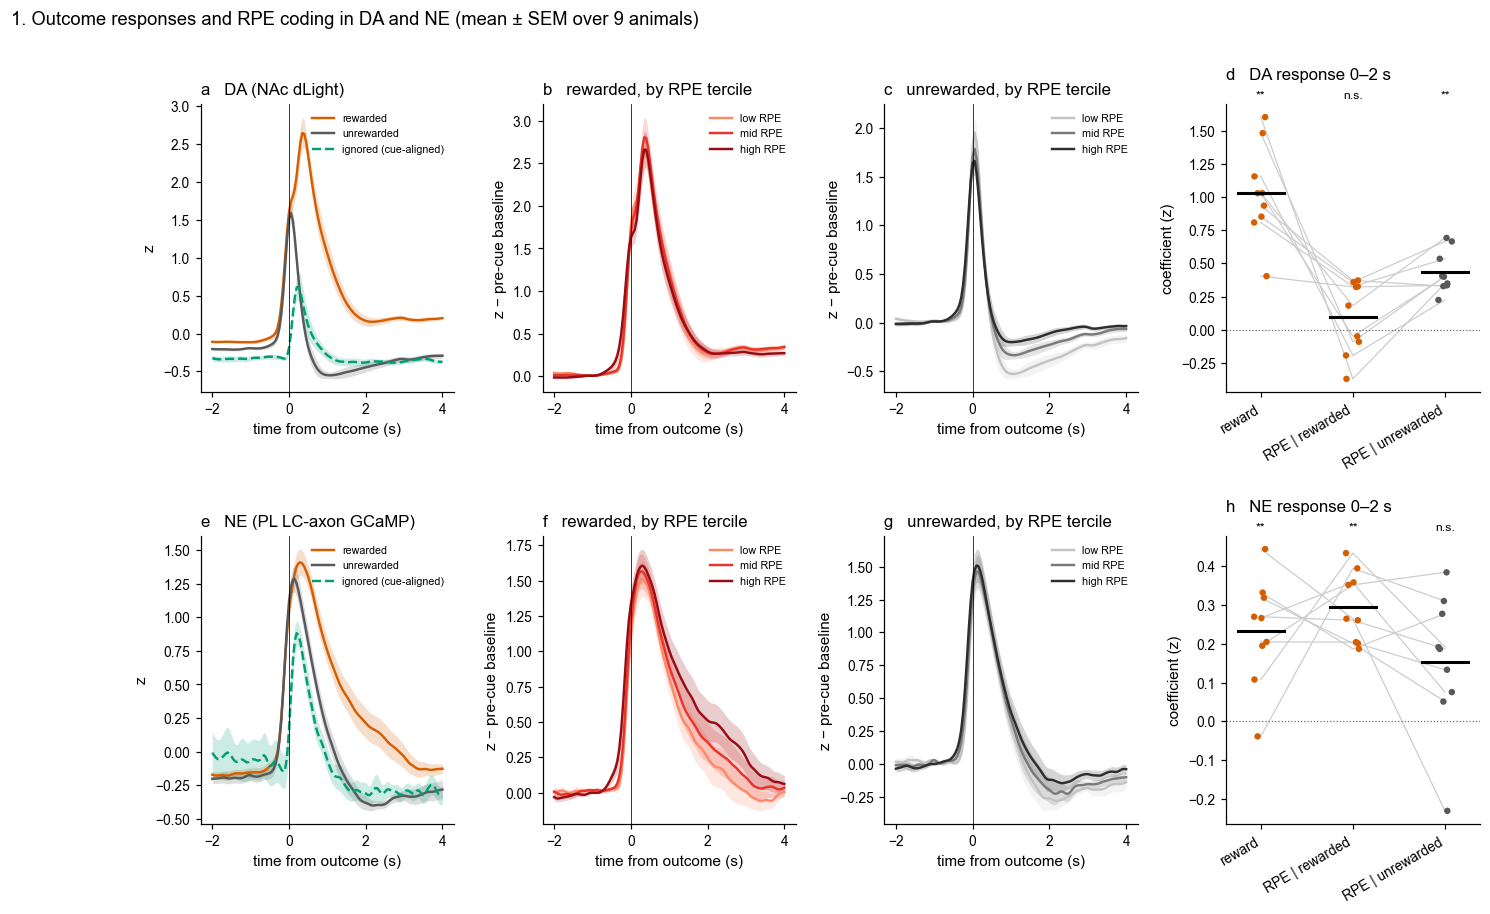

In [8]:
fig = plt.figure(figsize=(15, 8.5))
gs = GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.35)
seq = {"rew": plt.cm.Reds(np.linspace(0.4, 0.9, N_RPE_BINS)),
       "unrew": plt.cm.Greys(np.linspace(0.35, 0.85, N_RPE_BINS))}

for i, sig in enumerate(("da", "ne")):
    ax = fig.add_subplot(gs[i, 0])
    pu.plot_mean_sem(ax, LAGS, peth[(sig, "rewarded")], PALETTE["pos"], "rewarded")
    pu.plot_mean_sem(ax, LAGS, peth[(sig, "unrewarded")], "0.35", "unrewarded")
    pu.plot_mean_sem(ax, LAGS, peth[(sig, "ignored (cue)")], OKABE_ITO["bluish_green"],
                "ignored (cue-aligned)", ls="--")
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel("time from outcome (s)")
    ax.set_ylabel("z")
    ax.set_title(f"{'ae'[i]}   {SIG_LABEL[sig]}", loc="left")
    ax.legend(fontsize=7)
    style_ax(ax)
    for j, cls in enumerate(("rew", "unrew")):
        ax = fig.add_subplot(gs[i, 1 + j])
        for k in range(N_RPE_BINS):
            key = (sig, f"{cls} RPE{k}")
            if key in peth:
                pu.plot_mean_sem(ax, LAGS, peth[key], seq[cls][k],
                            ["low", "mid", "high"][k] + " RPE")
        ax.axvline(0, color="k", lw=0.5)
        ax.set_xlabel("time from outcome (s)")
        ax.set_ylabel("z − pre-cue baseline")
        ax.set_title(f"{'bf'[i] if j == 0 else 'cg'[i]}   "
                     f"{'rewarded' if cls == 'rew' else 'unrewarded'}, by RPE tercile", loc="left")
        ax.legend(fontsize=7)
        style_ax(ax)
    ax = fig.add_subplot(gs[i, 3])
    g = rpe_animal.xs((sig, "full"), level=["sig", "window"])
    pu.strip_by_measure(ax, g, ["reward", "rpe_rew", "rpe_unrew"],
                 ["reward", "RPE | rewarded", "RPE | unrewarded"],
                 [PALETTE["pos"], PALETTE["pos"], "0.35"], "coefficient (z)",
                 title=f"{'dh'[i]}   {sig.upper()} response 0–2 s")
fig.suptitle("1. Outcome responses and RPE coding in DA and NE "
             f"(mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_16_1_rpe_coding", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

Panels a and e are raw z; b, c, f and g subtract each trial's pre-cue baseline.

## 2. RPE coefficients over time

The same regression at every time point after the outcome, with the pre-cue baseline subtracted or entered as a covariate. Shading: SEM over animals; dots: Wilcoxon p < 0.05.

In [9]:
TR_LAGS = np.arange(-0.5, 3.0 + 1e-9, 1 / FS)
BASELINE_MODES = ("subtracted", "covariate")
tr_coef = {}  # (mode, sig, term) -> per-animal (n_lags,) coefficient traces
for subj in SUBJECTS:
    acc = {}
    for p in (p for p in pairs if p["subject"] == subj):
        g = resp[resp.session == p["session"]]
        if len(g) < 30:
            continue
        g = g.dropna(subset=RPE_NUISANCE + ["da_pre", "ne_pre"])
        r = g["rewarded"].to_numpy(float)
        rpe = g[RPE_COL].to_numpy(float)
        X0 = np.c_[np.ones(len(g)), r, rpe * r, rpe * (1 - r), g[RPE_NUISANCE].to_numpy(float)]
        for sig in ("da", "ne"):
            z = su.zscore(p[sig])
            Y = su.peri_event_grid(z, p["t0"], FS, g["reward_outcome_time_in_session"], TR_LAGS)
            pre = g[f"{sig}_pre"].to_numpy()
            ok = np.isfinite(Y).all(1)
            for mode in BASELINE_MODES:
                X, YY = (X0, Y - pre[:, None]) if mode == "subtracted" else (np.c_[X0, pre], Y)
                beta, *_ = np.linalg.lstsq(X[ok], YY[ok], rcond=None)
                for k, term in enumerate(("intercept", "reward", "rpe_rew", "rpe_unrew")):
                    acc.setdefault((mode, sig, term), []).append(beta[k])
    for key, v in acc.items():
        tr_coef.setdefault(key, []).append(np.mean(v, 0))
tr_coef = {k: np.stack(v) for k, v in tr_coef.items()}

# Mean coefficient in an early and a late part of the response, per animal.
EARLY, LATE = (0.0, 0.5), (0.75, 2.0)
rows = []
for mode in BASELINE_MODES:
    for sig in ("da", "ne"):
        for term in ("rpe_rew", "rpe_unrew"):
            for name, (a, b) in (("early", EARLY), ("late", LATE)):
                v = tr_coef[(mode, sig, term)][:, (TR_LAGS >= a) & (TR_LAGS < b)].mean(1)
                m, pv, n = st.wilcoxon_animals(v)
                rows.append(dict(baseline=mode, signal=sig, term=term, part=f"{name} {a}-{b} s",
                                 mean=m, p=pv, n_positive=f"{int((v > 0).sum())}/{n}"))
tr_summary = pd.DataFrame(rows).set_index(["signal", "term", "part", "baseline"]).sort_index()
tr_summary.round(3)

mean      p n_positive
signal term      part            baseline                           
da     rpe_rew   early 0.0-0.5 s covariate  -0.004  0.910        4/9
                                 subtracted  0.351  0.008        8/9
                 late 0.75-2.0 s covariate  -0.449  0.004        0/9
                                 subtracted -0.025  1.000        4/9
       rpe_unrew early 0.0-0.5 s covariate  -0.160  0.164        2/9
                                 subtracted  0.224  0.027        7/9
                 late 0.75-2.0 s covariate   0.074  0.164        7/9
                                 subtracted  0.524  0.004        9/9
ne     rpe_rew   early 0.0-0.5 s covariate   0.193  0.004        9/9
                                 subtracted  0.252  0.004        9/9
                 late 0.75-2.0 s covariate   0.273  0.004        9/9
                                 subtracted  0.327  0.004        9/9
       rpe_unrew early 0.0-0.5 s covariate   0.015  0.652        5/9
                                 subtracted  0.092  0.203        6/9
                 late 0.75-2.0 s covariate   0.117  0.129        6/9
                                 subtracted  0.191  0.039        8/9

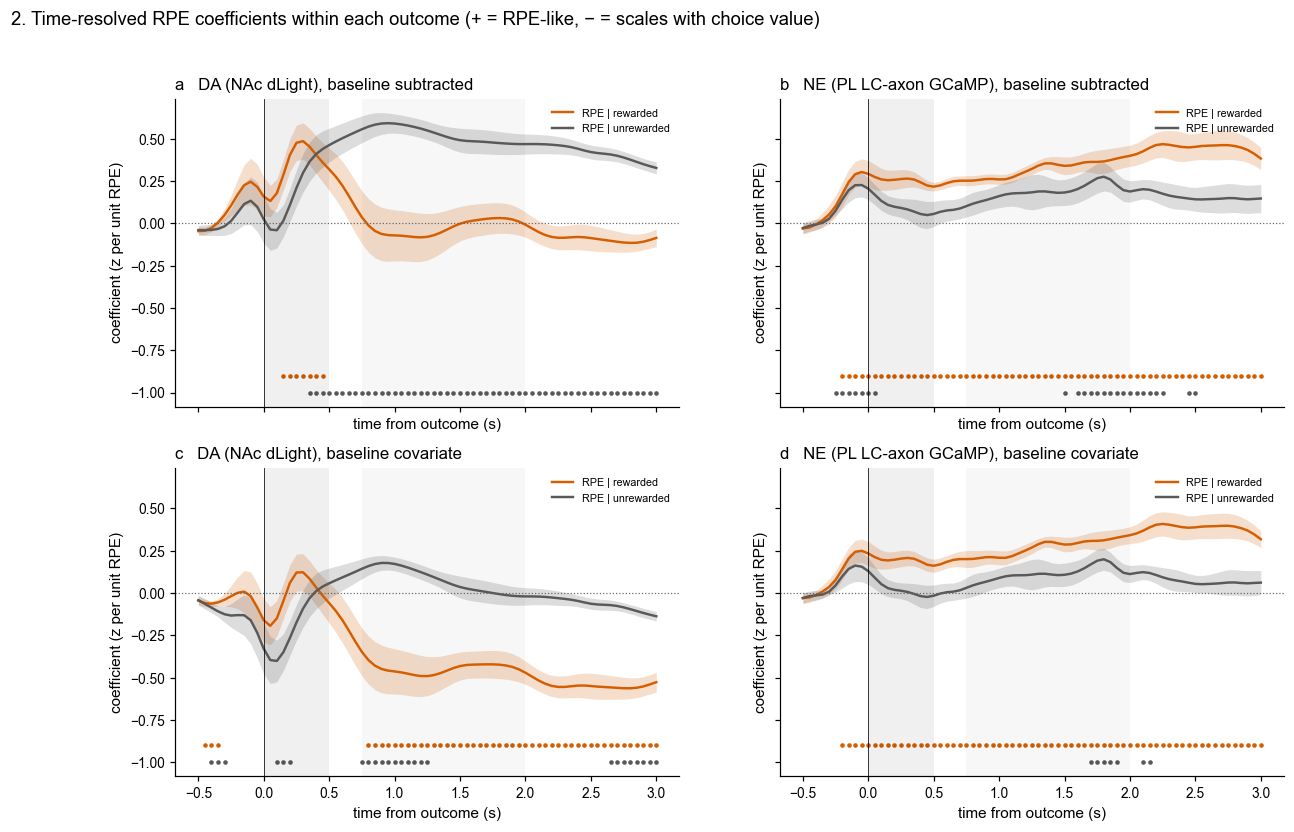

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True, sharex=True)
for (row, mode), (col_i, sig) in [(rm, cs) for rm in enumerate(BASELINE_MODES)
                                  for cs in enumerate(("da", "ne"))]:
    ax = axes[row, col_i]
    for term, col, lab in (("rpe_rew", PALETTE["pos"], "RPE | rewarded"),
                           ("rpe_unrew", "0.35", "RPE | unrewarded")):
        A = tr_coef[(mode, sig, term)]
        pu.plot_mean_sem(ax, TR_LAGS, A, col, lab)
        p_t = np.array([st.wilcoxon_animals(A[:, k])[1] for k in range(A.shape[1])])
        y_dot = -0.9 if term == "rpe_rew" else -1.0
        ax.scatter(TR_LAGS[p_t < 0.05], np.full((p_t < 0.05).sum(), y_dot), s=4, color=col)
    ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
    ax.axvline(0, color="k", lw=0.5)
    for (a, b), shade in ((EARLY, 0.06), (LATE, 0.03)):
        ax.axvspan(a, b, color="k", alpha=shade, lw=0)
    ax.set_xlabel("time from outcome (s)")
    ax.set_ylabel("coefficient (z per unit RPE)")
    ax.set_title(f"{'abcd'[2 * row + col_i]}   {SIG_LABEL[sig]}, baseline {mode}", loc="left")
    ax.legend(fontsize=7, loc="upper right")
    style_ax(ax)
fig.suptitle("2. Time-resolved RPE coefficients within each outcome "
             "(+ = RPE-like, − = scales with choice value)", x=0.01, ha="left")
save_fig(fig, "fip_16_2_rpe_timecourse", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3. DA vs NE coefficients

The 0–2 s coefficients compared between DA and NE: trial level (Pearson r of the two signals' outcome + RPE predictions, within session), session level (Spearman ρ, centred within animal), animal level (Spearman ρ of animal means).

In [11]:
TERMS = ["reward", "rpe_rew", "rpe_unrew"]
TERM_LABEL = {"reward": "reward", "rpe_rew": "RPE | rewarded", "rpe_unrew": "RPE | unrewarded"}
coef = rpe_terms.pivot_table(index=["subject", "session", "window"], columns="sig", values=TERMS)

# Trial level: correlation across trials of the two signals' outcome + RPE predictions.
rows = []
for (subj, sess), g in resp.groupby(["subject", "session"]):
    g = g.dropna(subset=RPE_NUISANCE)
    r = g["rewarded"].to_numpy(float)
    rpe = g[RPE_COL].to_numpy(float)
    X = np.c_[r, rpe * r, rpe * (1 - r)]
    d = dict(subject=subj, session=sess)
    for w in RESP_WINS:
        pred = {sig: X @ coef.loc[(subj, sess, w), [(t, sig) for t in TERMS]].to_numpy(float)
                for sig in ("da", "ne")}
        d[w] = st.corr(pd.DataFrame(pred), "da", "ne")[0]
    rows.append(d)
tuning_trial_animal = st.animal_means(pd.DataFrame(rows), list(RESP_WINS), by_session=False)

# Session level (centred within animal) and animal level: correlation of DA's and NE's coefficients.
coef_centred = coef - coef.groupby(level=["subject", "window"]).transform("mean")
coef_animal = coef.groupby(level=["subject", "window"]).mean()
rows = []
for w in RESP_WINS:
    m, p, n = st.wilcoxon_animals(tuning_trial_animal[w])
    rows.append(dict(window=w, level="trial", term="outcome + RPE fit", r=m, p=p, n=n))
    for level, tbl in (("session (within animal)", coef_centred), ("animal", coef_animal)):
        t = tbl.xs(w, level="window")
        for term in TERMS:
            rr, pp = stats.spearmanr(t[(term, "da")], t[(term, "ne")])
            rows.append(dict(window=w, level=level, term=term, r=rr, p=pp, n=len(t)))
tuning_summary = pd.DataFrame(rows).set_index(["window", "level", "term"])
tuning_summary.round(3)

r      p   n
window level                   term                               
early  trial                   outcome + RPE fit  0.581  0.004   9
       session (within animal) reward             0.261  0.011  95
                               rpe_rew            0.385  0.000  95
                               rpe_unrew          0.155  0.134  95
       animal                  reward             0.550  0.125   9
                               rpe_rew            0.717  0.030   9
                               rpe_unrew          0.483  0.187   9
late   trial                   outcome + RPE fit  0.881  0.004   9
       session (within animal) reward             0.208  0.044  95
                               rpe_rew            0.109  0.295  95
                               rpe_unrew          0.365  0.000  95
       animal                  reward            -0.033  0.932   9
                               rpe_rew           -0.517  0.154   9
                               rpe_unrew          0.383  0.308   9
full   trial                   outcome + RPE fit  0.894  0.004   9
       session (within animal) reward             0.226  0.027  95
                               rpe_rew            0.232  0.024  95
                               rpe_unrew          0.314  0.002  95
       animal                  reward             0.267  0.488   9
                               rpe_rew           -0.283  0.460   9
                               rpe_unrew          0.383  0.308   9

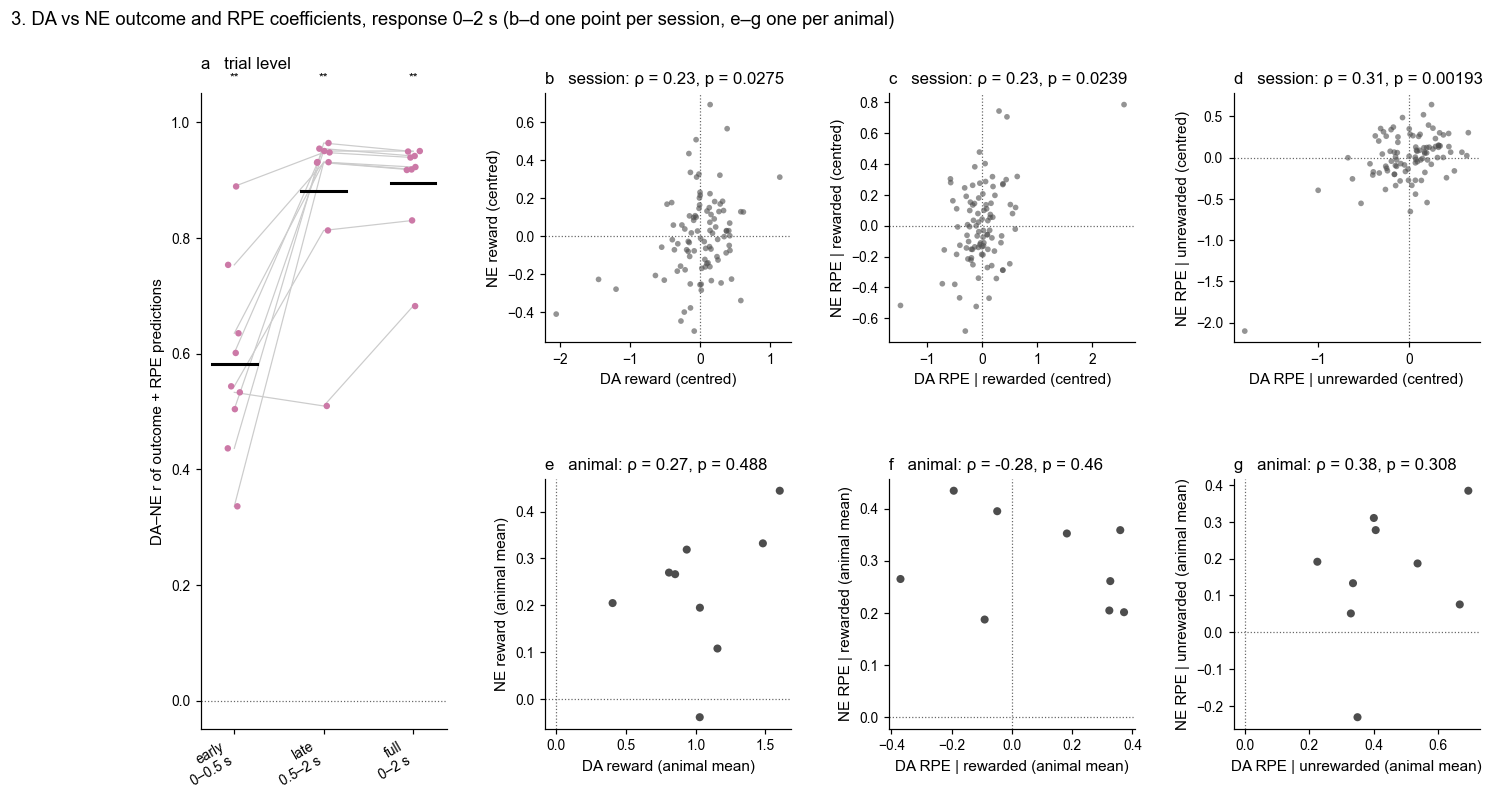

In [12]:
fig = plt.figure(figsize=(15, 7.5))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 1], hspace=0.55, wspace=0.4)

ax = fig.add_subplot(gs[:, 0])
pu.strip_by_measure(ax, tuning_trial_animal, list(RESP_WINS), ["early\n0–0.5 s", "late\n0.5–2 s", "full\n0–2 s"],
             [PALETTE["accent"]] * 3, "DA–NE r of outcome + RPE predictions",
             title="a   trial level")
ax.set_ylim(top=1.05)

for row_i, (level, tbl, xlab) in enumerate((("session (within animal)", coef_centred, "centred"),
                                            ("animal", coef_animal, "animal mean"))):
    t = tbl.xs("full", level="window")
    for j, term in enumerate(TERMS):
        ax = fig.add_subplot(gs[row_i, 1 + j])
        x, y = t[(term, "da")], t[(term, "ne")]
        ax.scatter(x, y, s=14 if row_i == 0 else 28, color="0.3", edgecolor="none",
                   alpha=0.6 if row_i == 0 else 1)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.axvline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        rr, pp = tuning_summary.loc[("full", level, term), ["r", "p"]]
        ax.set_xlabel(f"DA {TERM_LABEL[term]} ({xlab})")
        ax.set_ylabel(f"NE {TERM_LABEL[term]} ({xlab})")
        letter = "bcdefg"[3 * row_i + j]
        ax.set_title(f"{letter}   {level.split()[0]}: ρ = {rr:.2f}, p = {pp:.3g}", loc="left")
        style_ax(ax)
fig.suptitle("3. DA vs NE outcome and RPE coefficients, response 0–2 s "
             "(b–d one point per session, e–g one per animal)", x=0.01, ha="left")
save_fig(fig, "fip_16_3_tuning_similarity", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 4. Trial coupling beyond outcome and RPE

DA–NE correlation of outcome responses per session: all trials, within each outcome, and residual after regressing on outcome and RPE within outcome (`fu.residualize`). `fip_15` gives the total and within-outcome correlations on Rachel's `data_z_norm` windows.

In [13]:
RPE_COVS = ["rewarded", "rpe_x_rew", "rpe_x_unrew"]  # outcome + RPE within each outcome

for w in RESP_WINS:
    for sig in ("da", "ne"):
        resp[f"{sig}_{w}_resid"] = fu.residualize(resp, f"{sig}_{w}", RPE_COVS)

rows = []
for (subj, sess), g in resp.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for w in RESP_WINS:
        d[f"total_{w}"] = st.corr(g, f"da_{w}", f"ne_{w}")[0]
        d[f"rewarded_{w}"] = st.corr(g[g.rewarded], f"da_{w}", f"ne_{w}")[0]
        d[f"unrewarded_{w}"] = st.corr(g[~g.rewarded], f"da_{w}", f"ne_{w}")[0]
        d[f"residual_{w}"] = st.corr(g, f"da_{w}_resid", f"ne_{w}_resid")[0]
    rows.append(d)
resp_corr = pd.DataFrame(rows)
resp_corr_animal = st.animal_means(resp_corr, [c for c in resp_corr if "_" in c and c not in ("subject", "session")], by_session=False)

rows = []
for c in resp_corr_animal:
    m, p, n = st.wilcoxon_animals(resp_corr_animal[c])
    kind, w = c.rsplit("_", 1)
    rows.append(dict(window=w, correlation=kind, mean_r=m, p=p, n_positive=int((resp_corr_animal[c] > 0).sum()), n=n))
pd.DataFrame(rows).set_index(["window", "correlation"]).round(3)

mean_r      p  n_positive  n
window correlation                              
early  total         0.176  0.004           9  9
       rewarded      0.162  0.004           9  9
       unrewarded    0.116  0.020           8  9
       residual      0.143  0.004           9  9
late   total         0.323  0.008           8  9
       rewarded      0.146  0.020           8  9
       unrewarded    0.121  0.074           7  9
       residual      0.125  0.027           8  9
full   total         0.313  0.004           9  9
       rewarded      0.144  0.020           8  9
       unrewarded    0.124  0.055           7  9
       residual      0.131  0.027           8  9

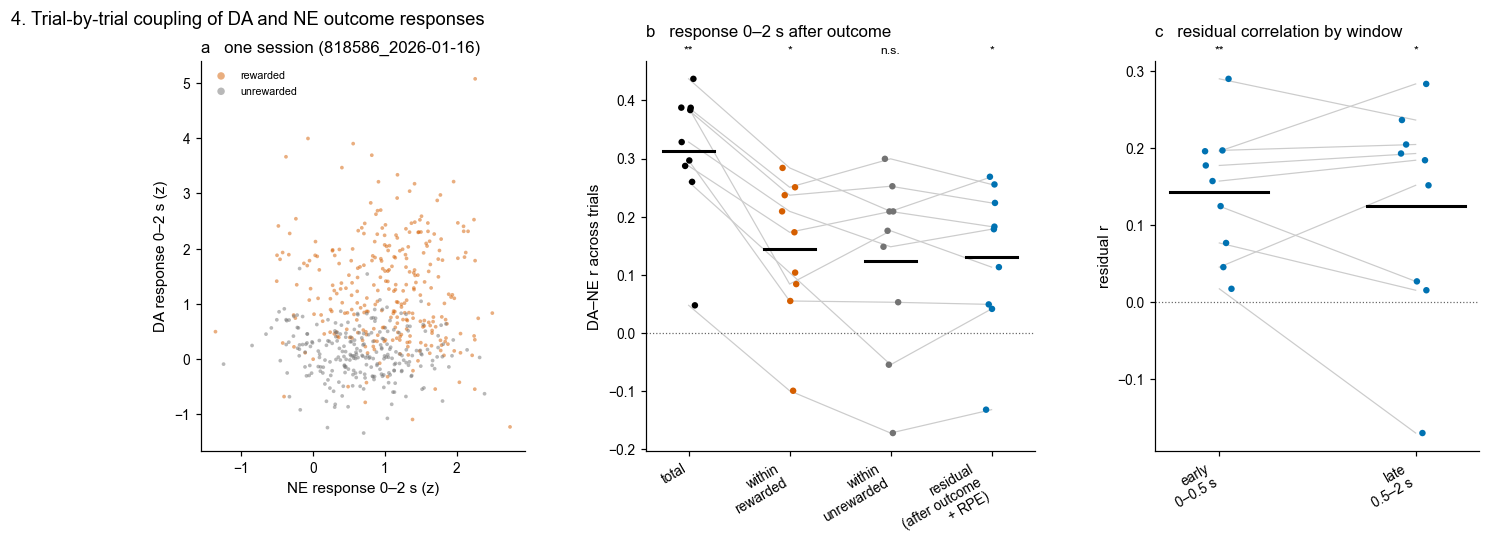

In [14]:
fig = plt.figure(figsize=(15, 4.6))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1.2, 1], wspace=0.35)

ax = fig.add_subplot(gs[0])
g = resp[resp.session == ex["session"]]
for rew, col, lab in ((True, PALETTE["pos"], "rewarded"), (False, "0.45", "unrewarded")):
    h = g[g.rewarded == rew]
    ax.scatter(h["ne_full"], h["da_full"], s=6, color=col, alpha=0.5, label=lab, edgecolor="none")
ax.set_xlabel("NE response 0–2 s (z)")
ax.set_ylabel("DA response 0–2 s (z)")
ax.set_title(f"a   one session ({ex['session']})", loc="left")
ax.legend(fontsize=7, markerscale=2)
style_ax(ax)

ax = fig.add_subplot(gs[1])
kinds = ["total", "rewarded", "unrewarded", "residual"]
pu.strip_by_measure(ax, resp_corr_animal, [f"{k}_full" for k in kinds],
             ["total", "within\nrewarded", "within\nunrewarded", "residual\n(after outcome\n+ RPE)"],
             ["k", PALETTE["pos"], "0.45", OKABE_ITO["blue"]],
             "DA–NE r across trials", title="b   response 0–2 s after outcome")

ax = fig.add_subplot(gs[2])
pu.strip_by_measure(ax, resp_corr_animal, [f"residual_{w}" for w in ("early", "late")],
             ["early\n0–0.5 s", "late\n0.5–2 s"], [OKABE_ITO["blue"]] * 2,
             "residual r", title="c   residual correlation by window")
fig.suptitle("4. Trial-by-trial coupling of DA and NE outcome responses", x=0.01, ha="left")
save_fig(fig, "fip_16_4_trial_coupling", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

### 4b. Controls on the residual correlation

Response time, trial position, or both pre-cue baselines added to the outcome + RPE model one at a time, on the same trials.

In [15]:
CONTROLS = {
    "outcome + RPE": [],
    "+ response time": ["response_time"],
    "+ trial position": ["trial_frac"],
    "+ both baselines": ["da_pre", "ne_pre"],
}
ctrl = resp.dropna(subset=sorted({c for v in CONTROLS.values() for c in v})).copy()
for name, extra_covs in CONTROLS.items():
    for w in RESP_WINS:
        for sig in ("da", "ne"):
            ctrl[f"{sig}_{w}_{name}"] = fu.residualize(ctrl, f"{sig}_{w}", RPE_COVS + extra_covs)

rows = []
for (subj, sess), g in ctrl.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for name in CONTROLS:
        for w in RESP_WINS:
            d[f"{name}|{w}"] = st.corr(g, f"da_{w}_{name}", f"ne_{w}_{name}")[0]
    rows.append(d)
ctrl_corr = pd.DataFrame(rows)
ctrl_corr_animal = st.animal_means(ctrl_corr, [c for c in ctrl_corr if "|" in c], by_session=False)

rows = []
for w in RESP_WINS:
    base = ctrl_corr_animal[f"outcome + RPE|{w}"]
    for name in CONTROLS:
        v = ctrl_corr_animal[f"{name}|{w}"]
        m, p, n = st.wilcoxon_animals(v)
        dm, dp = ((0.0, np.nan) if name == "outcome + RPE"
                  else st.wilcoxon_animals(v - base)[:2])
        rows.append(dict(window=w, model=name, mean_r=m, p=p, n_positive=int((v > 0).sum()),
                         change_vs_outcome_rpe=dm, p_change=dp))
ctrl_summary = pd.DataFrame(rows).set_index(["window", "model"])
ctrl_summary.round(3)

mean_r      p  n_positive  change_vs_outcome_rpe  p_change
window model                                                                       
early  outcome + RPE      0.143  0.004           9                  0.000       NaN
       + response time    0.126  0.008           8                 -0.017     0.074
       + trial position   0.154  0.004           9                  0.011     0.496
       + both baselines   0.141  0.004           9                 -0.001     1.000
late   outcome + RPE      0.125  0.027           8                  0.000       NaN
       + response time    0.127  0.027           8                  0.002     0.652
       + trial position   0.130  0.027           8                  0.004     0.426
       + both baselines   0.113  0.074           7                 -0.013     0.203
full   outcome + RPE      0.131  0.027           8                  0.000       NaN
       + response time    0.135  0.027           8                  0.004     0.301
       + trial position   0.139  0.027           8                  0.008     0.301
       + both baselines   0.118  0.039           8                 -0.013     0.301

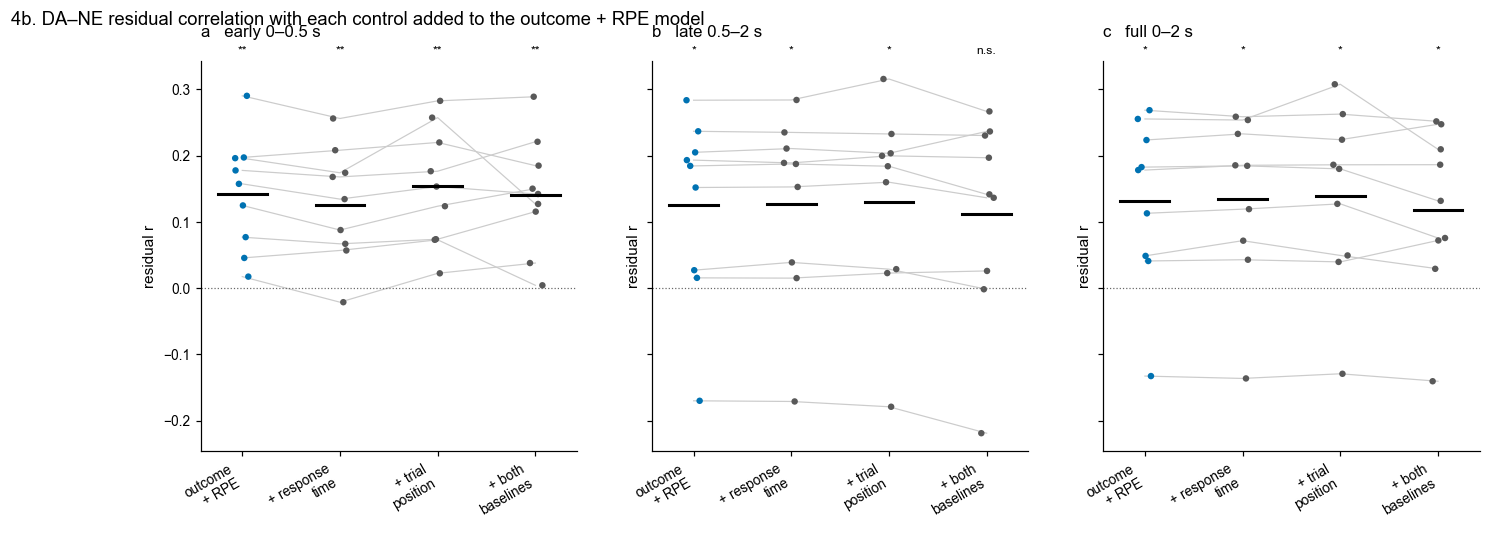

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
names = list(CONTROLS)
for ax, (w, (a, b)) in zip(axes, RESP_WINS.items()):
    pu.strip_by_measure(ax, ctrl_corr_animal, [f"{n}|{w}" for n in names],
                 ["outcome\n+ RPE", "+ response\ntime", "+ trial\nposition", "+ both\nbaselines"],
                 [OKABE_ITO["blue"]] + ["0.35"] * 3, "residual r",
                 title=f"{'abc'[list(RESP_WINS).index(w)]}   {w} {a:g}–{b:g} s")
fig.suptitle("4b. DA–NE residual correlation with each control added to the outcome + RPE "
             "model", x=0.01, ha="left")
save_fig(fig, "fip_16_4b_residual_controls", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. Pre-cue baselines

- Pre-cue baseline (−1 to 0 s) against total value `Q_sum`.
- DA–NE baseline correlation: trial by trial, after regressing out value and trial position, and as
  a 20-trial running mean.

`fip_13` §5 has the continuous DA–NE correlation by timescale, raw and with the task removed.

In [17]:
bl = trials.dropna(subset=["da_pre", "ne_pre", "Q_sum"]).copy()
for sig in ("da", "ne"):
    bl[f"{sig}_pre_resid"] = fu.residualize(bl, f"{sig}_pre", ["Q_sum", "trial_frac"])
    bl[f"{sig}_pre_c"] = bl.groupby("session")[f"{sig}_pre"].transform(lambda x: x - x.mean())
    bl[f"{sig}_pre_slow"] = bl.groupby("session")[f"{sig}_pre_c"].transform(
        lambda x: x.rolling(BL_WINDOW, center=True, min_periods=BL_WINDOW // 2).mean())

rows = []
for (subj, sess), g in bl.groupby(["subject", "session"]):
    rows.append(dict(subject=subj, session=sess,
                     da_value=stats.spearmanr(g.da_pre, g.Q_sum)[0],
                     ne_value=stats.spearmanr(g.ne_pre, g.Q_sum)[0],
                     r_raw=st.corr(g, "da_pre", "ne_pre")[0],
                     r_resid=st.corr(g, "da_pre_resid", "ne_pre_resid")[0],
                     r_slow=st.corr(g, "da_pre_slow", "ne_pre_slow")[0]))
bl_sess = pd.DataFrame(rows)
bl_animal = st.animal_means(bl_sess, ["da_value", "ne_value", "r_raw", "r_resid", "r_slow"],
                            by_session=False)
for c in bl_animal:
    m, p, n = st.wilcoxon_animals(bl_animal[c])
    print(f"{c:9s} mean {m:+.3f}  p = {p:.4f}  n_positive = {(bl_animal[c] > 0).sum()}/{n}")

# Baseline by value quintile (within session), for panel a.
bl["q_bin"] = bl.groupby("session")["Q_sum"].transform(
    lambda x: pd.qcut(x.rank(method="first"), 5, labels=False))
q_curve = bl.groupby(["subject", "session", "q_bin"])[["da_pre", "ne_pre"]].mean() \
            .groupby(level=["subject", "q_bin"]).mean()

da_value  mean +0.350  p = 0.0039  n_positive = 9/9
ne_value  mean +0.047  p = 0.0195  n_positive = 8/9
r_raw     mean +0.069  p = 0.1289  n_positive = 6/9
r_resid   mean +0.064  p = 0.1289  n_positive = 6/9
r_slow    mean +0.114  p = 0.0195  n_positive = 7/9


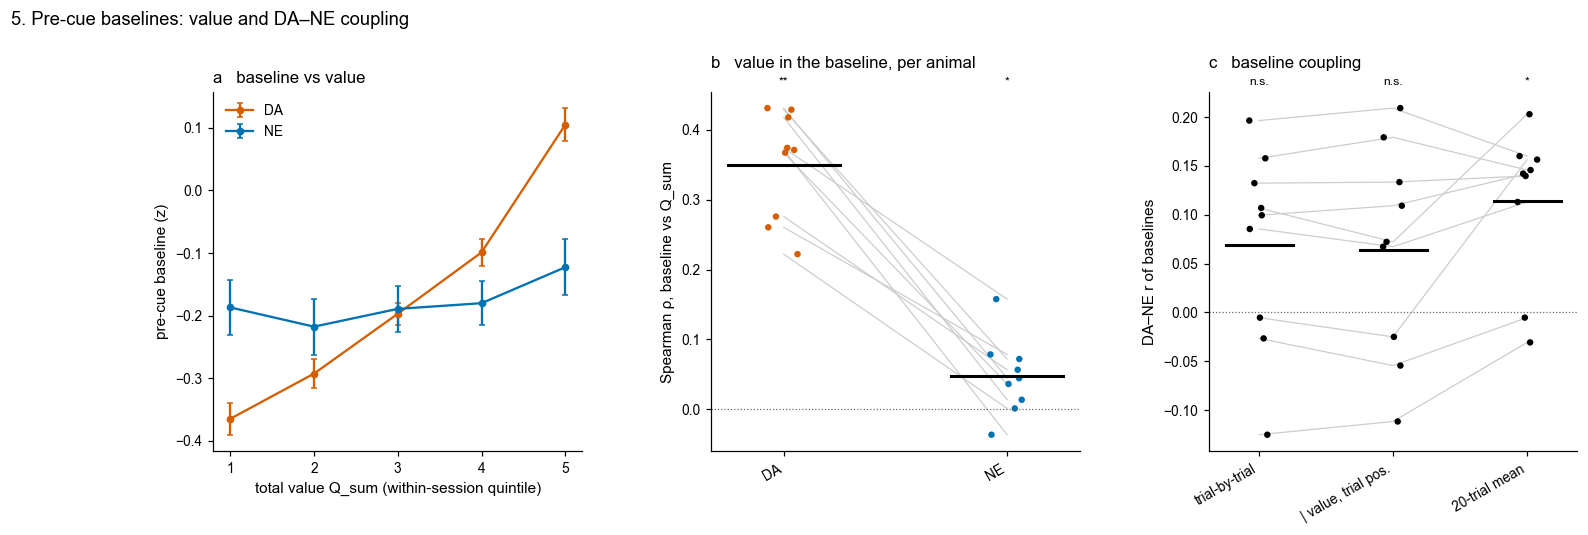

In [18]:
fig = plt.figure(figsize=(16, 4.6))
gs = GridSpec(1, 3, figure=fig, wspace=0.35, top=0.82)
ax = fig.add_subplot(gs[0])
for sig in ("da", "ne"):
    c = q_curve[f"{sig}_pre"].unstack("q_bin")
    m_, se, _ = st.mean_sem(c)
    ax.errorbar(np.arange(5) + 1, m_, se, color=SIG_COLOR[sig], marker="o", ms=4, capsize=2,
                label=sig.upper())
ax.set_xlabel("total value Q_sum (within-session quintile)")
ax.set_ylabel("pre-cue baseline (z)")
ax.set_title("a   baseline vs value", loc="left")
ax.legend()
style_ax(ax)

ax = fig.add_subplot(gs[1])
pu.strip_by_measure(ax, bl_animal, ["da_value", "ne_value"], ["DA", "NE"],
                    [SIG_COLOR["da"], SIG_COLOR["ne"]], "Spearman ρ, baseline vs Q_sum",
                    title="b   value in the baseline, per animal")
ax = fig.add_subplot(gs[2])
pu.strip_by_measure(ax, bl_animal, ["r_raw", "r_resid", "r_slow"],
                    ["trial-by-trial", "| value, trial pos.", f"{BL_WINDOW}-trial mean"],
                    ["k", "k", "k"], "DA–NE r of baselines", title="c   baseline coupling")
fig.suptitle("5. Pre-cue baselines: value and DA–NE coupling", x=0.01, ha="left")
save_fig(fig, "fip_16_5_baselines", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. RPE terms with movement as a covariate

Per trial, the mean of each signal 0–2 s after the outcome minus its mean 1 s before the go cue
(`fu.trial_measures`; ME the same way). **a.** Outcome-aligned ME by outcome. **b.** `fu.fit_rpe_terms`
per session for DA, NE and ME (`response ~ reward + RPE·rewarded + RPE·unrewarded + RT + trial
position`), on responded trials without extra water, leaving out flat-RPE sessions. **c.** The DA
and NE terms again with the trial's ME response as a further covariate. Sessions with a usable bottom camera only.

In [19]:
me_rpe_rows, out_traces = [], {o: [] for o in OUT_COLOR}
for p in me_pairs:
    tr = fu.trial_measures(p, {"out": OUTCOME_WIN}, baseline=BASELINE_WIN)
    cue = tr["goCue_start_time_in_session"].to_numpy()
    out = tr["reward_outcome_time_in_session"].to_numpy()
    me = p["z"]["me"]
    tr["me_pre"] = su.window_mean_grid(me, p["t0"], FS, cue, *BASELINE_WIN)
    tr["me_out"] = su.window_mean_grid(me, p["t0"], FS, out, *OUTCOME_WIN) - tr["me_pre"]
    tr = tr[tr["responded"] & ~(tr["extra_reward"].fillna(0) > 0)]
    for o, m in (("rewarded", tr["rewarded"]), ("unrewarded", ~tr["rewarded"])):
        out_traces[o].append((p["subject"], np.nanmean(
            su.peri_event_grid(me, p["t0"], FS, tr.loc[m, "reward_outcome_time_in_session"], ETA_LAGS), 0)))
    if tr.groupby("rewarded")["RPE_earned"].std().min() < MIN_RPE_SD:
        continue
    r = dict(subject=p["subject"], session=p["session"])
    for s in SIG:
        b = fu.fit_rpe_terms(tr, f"{s}_out", covariates=RPE_NUISANCE)
        r.update({f"{s}_{t}": b[t] for t in TERMS})
    for s in ("da", "ne"):
        b = fu.fit_rpe_terms(tr, f"{s}_out", covariates=RPE_NUISANCE + ["me_out"])
        r.update({f"{s}_{t}_withME": b[t] for t in TERMS})
        r[f"{s}_me_beta"] = b["me_out"]
    me_rpe_rows.append(r)
me_rpe_sess = pd.DataFrame(me_rpe_rows)
me_rpe_animal = st.animal_means(me_rpe_sess, [c for c in me_rpe_sess if c not in ("subject", "session")],
                             by_session=False)
print(f"{len(me_rpe_sess)} sessions in the RPE fits ({len(me_pairs) - len(me_rpe_sess)} flat-RPE sessions left out)")
report("RPE terms of DA, NE and ME", me_rpe_animal, [f"{s}_{t}" for s in SIG for t in TERMS])
report("DA and NE terms with ME as a covariate, and the ME coefficient", me_rpe_animal,
       [f"{s}_{t}_withME" for s in ("da", "ne") for t in TERMS] + ["da_me_beta", "ne_me_beta"])
for s in ("da", "ne"):
    for t in TERMS:
        me_rpe_animal[f"{s}_{t}_change"] = me_rpe_animal[f"{s}_{t}_withME"] - me_rpe_animal[f"{s}_{t}"]
report("change in DA and NE terms when ME is added", me_rpe_animal,
       [f"{s}_{t}_change" for s in ("da", "ne") for t in TERMS])

87 sessions in the RPE fits (1 flat-RPE sessions left out)
── RPE terms of DA, NE and ME
     measure  mean    sem       p  n
   da_reward  1.05  0.115 0.00391  9
  da_rpe_rew 0.091  0.091   0.359  9
da_rpe_unrew 0.457 0.0495 0.00391  9
   ne_reward 0.228 0.0394 0.00781  9
  ne_rpe_rew 0.326   0.03 0.00391  9
ne_rpe_unrew  0.16 0.0571  0.0273  9
   me_reward 0.721 0.0855 0.00391  9
  me_rpe_rew 0.154 0.0639  0.0742  9
me_rpe_unrew 0.161 0.0781  0.0977  9

── DA and NE terms with ME as a covariate, and the ME coefficient
            measure   mean    sem       p  n
   da_reward_withME  0.934  0.105 0.00391  9
  da_rpe_rew_withME 0.0914 0.0944   0.359  9
da_rpe_unrew_withME  0.443 0.0468 0.00391  9
   ne_reward_withME -0.292 0.0779 0.00781  9
  ne_rpe_rew_withME  0.222 0.0643 0.00391  9
ne_rpe_unrew_withME  0.045 0.0432   0.652  9
         da_me_beta  0.125 0.0509  0.0391  9
         ne_me_beta  0.708 0.0249 0.00391  9

── change in DA and NE terms when ME is added
            measure   

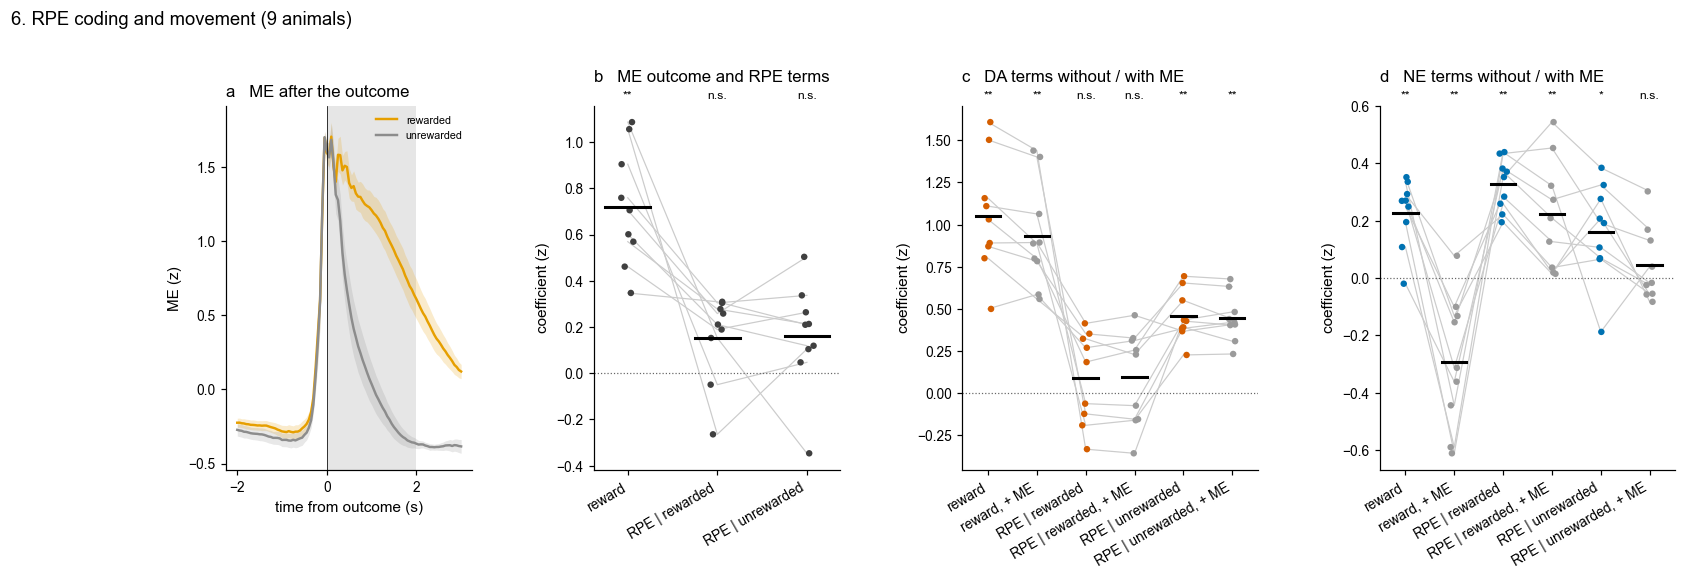

In [20]:
fig = plt.figure(figsize=(17, 4.8))
gs = GridSpec(1, 4, figure=fig, wspace=0.45, top=0.8, width_ratios=[1, 1, 1.2, 1.2])

ax = fig.add_subplot(gs[0])
for o in OUT_COLOR:
    pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(out_traces[o]), OUT_COLOR[o], o)
ax.axvline(0, color="k", lw=0.5)
ax.axvspan(*OUTCOME_WIN, color="0.9", lw=0, zorder=0)
ax.set_xlabel("time from outcome (s)")
ax.set_ylabel("ME (z)")
ax.set_title("a   ME after the outcome", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[1])
pu.strip_by_measure(ax, me_rpe_animal, [f"me_{t}" for t in TERMS], [TERM_LABEL[t] for t in TERMS],
                    [SIG_COLOR["me"]] * 3, "coefficient (z)", title="b   ME outcome and RPE terms")
for j, s in enumerate(("da", "ne")):
    ax = fig.add_subplot(gs[2 + j])
    cols = [c for t in TERMS for c in (f"{s}_{t}", f"{s}_{t}_withME")]
    labels = [l for t in TERMS for l in (TERM_LABEL[t], f"{TERM_LABEL[t]}, + ME")]
    pu.strip_by_measure(ax, me_rpe_animal, cols, labels, [SIG_COLOR[s], NULL_COLOR] * 3,
                        "coefficient (z)", title=f"{'cd'[j]}   {s.upper()} terms without / with ME")
fig.suptitle(f"6. RPE coding and movement ({N_ME_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_16_6_rpe_movement", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 7. Numbers

One row per measure: mean over animals, Wilcoxon p against zero, animals positive.

In [21]:
def row(section, measure, values):
    m, p, n = st.wilcoxon_animals(values)
    v = np.asarray(values, float)
    return dict(section=section, measure=measure, mean=round(m, 3), p=round(p, 4),
                animals_positive=f"{int((v > 0).sum())}/{n}")


g_da = rpe_animal.xs(("da", "full"), level=["sig", "window"])
g_ne = rpe_animal.xs(("ne", "full"), level=["sig", "window"])
S = [row("1", f"{s.upper()} {TERM_LABEL[t]}, 0–2 s", g[t]) for s, g in (("DA", g_da), ("NE", g_ne)) for t in TERMS]
S += [row("3", f"trial-level r of outcome + RPE predictions, {w}", tuning_trial_animal[w]) for w in RESP_WINS]
S += [row("4", f"{k} r, outcome response 0–2 s", resp_corr_animal[f"{k}_full"])
      for k in ("total", "rewarded", "unrewarded", "residual")]
S += [row("4b", f"residual r, {n}", ctrl_corr_animal[f"{n}|full"]) for n in CONTROLS if n != "outcome + RPE"]
S += [row("5", "DA baseline vs value ρ", bl_animal["da_value"]),
      row("5", "NE baseline vs value ρ", bl_animal["ne_value"]),
      row("5", "baseline r, trial-by-trial", bl_animal["r_raw"]),
      row("5", "baseline r | value, trial position", bl_animal["r_resid"]),
      row("5", f"baseline r, {BL_WINDOW}-trial mean", bl_animal["r_slow"])]
S += [row("6", f"{s.upper()} {TERM_LABEL[t]}", me_rpe_animal[f"{s}_{t}"]) for s in SIG for t in TERMS]
S += [row("6", f"{s.upper()} {TERM_LABEL[t]}: change with ME", me_rpe_animal[f"{s}_{t}_change"])
      for s in ("da", "ne") for t in TERMS]
pd.DataFrame(S).set_index(["section", "measure"])

mean       p animals_positive
section measure                                                                          
1       DA reward, 0–2 s                                   1.034  0.0039              9/9
        DA RPE | rewarded, 0–2 s                           0.096  0.4258              5/9
        DA RPE | unrewarded, 0–2 s                         0.438  0.0039              9/9
        NE reward, 0–2 s                                   0.234  0.0078              8/9
        NE RPE | rewarded, 0–2 s                           0.295  0.0039              9/9
        NE RPE | unrewarded, 0–2 s                         0.153  0.0547              8/9
3       trial-level r of outcome + RPE predictions, early  0.581  0.0039              9/9
        trial-level r of outcome + RPE predictions, late   0.881  0.0039              9/9
        trial-level r of outcome + RPE predictions, full   0.894  0.0039              9/9
4       total r, outcome response 0–2 s                    0.313  0.0039              9/9
        rewarded r, outcome response 0–2 s                 0.144  0.0195              8/9
        unrewarded r, outcome response 0–2 s               0.124  0.0547              7/9
        residual r, outcome response 0–2 s                 0.131  0.0273              8/9
4b      residual r, + response time                        0.135  0.0273              8/9
        residual r, + trial position                       0.139  0.0273              8/9
        residual r, + both baselines                       0.118  0.0391              8/9
5       DA baseline vs value ρ                             0.350  0.0039              9/9
        NE baseline vs value ρ                             0.047  0.0195              8/9
        baseline r, trial-by-trial                         0.069  0.1289              6/9
        baseline r | value, trial position                 0.064  0.1289              6/9
        baseline r, 20-trial mean                          0.114  0.0195              7/9
6       DA reward                                          1.052  0.0039              9/9
        DA RPE | rewarded                                  0.091  0.3594              5/9
        DA RPE | unrewarded                                0.457  0.0039              9/9
        NE reward                                          0.228  0.0078              8/9
        NE RPE | rewarded                                  0.326  0.0039              9/9
        NE RPE | unrewarded                                0.160  0.0273              8/9
        ME reward                                          0.721  0.0039              9/9
        ME RPE | rewarded                                  0.154  0.0742              7/9
        ME RPE | unrewarded                                0.161  0.0977              8/9
        DA reward: change with ME                         -0.118  0.0273              2/9
        DA RPE | rewarded: change with ME                  0.000  0.8203              4/9
        DA RPE | unrewarded: change with ME               -0.014  0.7344              4/9
        NE reward: change with ME                         -0.520  0.0039              0/9
        NE RPE | rewarded: change with ME                 -0.104  0.1289              2/9
        NE RPE | unrewarded: change with ME               -0.115  0.0742              1/9